#  IMDb Top 1000 Movies — Data Analysis Project
>>**By:** Ganna Amr Emad Eldin  
**Course:**  Data Mining   
**Dataset:** IMDb Top 1000 Movies (`imdb_raw.csv`)  
**Tools:** NumPy · Pandas · Matplotlib  
##  Supervision
>>- **Dr.** Mahmoud El Sabbagh  
>>- **Eng.** Mohamed Amin  

---

## Project Roadmap

| Section | Coverage |
|---------|----------|
| A | Data Import & Exploration |
| B | Array Programming with NumPy |
| C | Essential Pandas Functionality |
| D | Data Cleaning & Transformation |
| Bonus | Data Visualizations with Matplotlib |


---
## Section A — Data Import & Exploration
We start by importing all necessary libraries and loading the raw CSV file into a Pandas DataFrame.  
This is the foundation for every subsequent analysis step.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print(" Libraries loaded successfully")

 Libraries loaded successfully


### A.1 — Loading the Dataset

The dataset is loaded directly from CSV using `pd.read_csv()`.  
We immediately check its **shape** to confirm it satisfies the minimum 500-row requirement.


In [2]:
df = pd.read_csv(r"E:\data_mining_project\imdb_raw.csv")

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Minimum row requirement (500): {' PASSED' if df.shape[0] >= 500 else ' FAILED'}")


Dataset shape : 1,000 rows × 8 columns
Minimum row requirement (500):  PASSED


### A.2 — Data Types

Understanding each column's dtype guides every downstream decision:  
- Object (string) columns may need parsing or encoding.  
- Numeric columns are candidates for statistical analysis.


In [3]:
print("=" * 40)
print("Column Data Types")
print("=" * 40)
print(df.dtypes.to_string())

Column Data Types
title            object
director         object
release_year     object
runtime          object
genre            object
rating          float64
metascore         int64
gross            object


### A.3 — First 10 Rows

A quick visual scan of real data helps spot formatting quirks
(e.g., `$` signs in `gross`, units in `runtime`, parentheses in `release_year`).


In [4]:
df.head(10)


,title,director,release_year,runtime,genre,rating,metascore,gross
0,The Shawshank Redemption,Frank Darabont,(1994),142 min,Drama,9.3,82,$28.34M
1,The Godfather,Francis Ford Coppola,(1972),175 min,"Crime, Drama",9.2,100,$134.97M
2,The Dark Knight,Christopher Nolan,(2008),152 min,"Action, Crime, Drama",9.0,84,$534.86M
3,Schindler's List,Steven Spielberg,(1993),195 min,"Biography, Drama, History",9.0,95,$96.90M
4,12 Angry Men,Sidney Lumet,(1957),96 min,"Crime, Drama",9.0,97,$4.36M
5,The Lord of the Rings: The Return of the King,Peter Jackson,(2003),201 min,"Action, Adventure, Drama",9.0,94,$377.85M
6,The Godfather Part II,Francis Ford Coppola,(1974),202 min,"Crime, Drama",9.0,90,$57.30M
7,Spider-Man: Across the Spider-Verse,Joaquim Dos Santos,(2023),140 min,"Animation, Action, Adventure",8.9,86,0
8,Pulp Fiction,Quentin Tarantino,(1994),154 min,"Crime, Drama",8.9,95,$107.93M
9,Inception,Christopher Nolan,(2010),148 min,"Action, Adventure, Sci-Fi",8.8,74,$292.58M


---
## Section B — Array Programming with NumPy
Before running NumPy operations we perform the minimal cleaning needed to get  
numeric arrays: stripping currency symbols, unit suffixes, and parentheses.  
Full cleaning is documented in Section D.


In [5]:
df = df.copy()
# release_year: "(1994)" → 1994
df['release_year'] = df['release_year'].str.extract(r'(\d{4})').astype(int)

# runtime: "142 min" → 142
df['runtime'] = df['runtime'].str.extract(r'(\d+)').astype(int)

# gross: "$28.34M" → 28.34  (keep in millions; replace bare "0" with NaN)
df['gross'] = (
    df['gross']
    .str.replace(r'[\$M]', '', regex=True)   # strip $ and M
    .replace('0', np.nan)                     # "0" means data missing
    .astype(float)
)

print("Parsed columns — sample values:")
print(df[['release_year', 'runtime', 'gross']].head())


Parsed columns — sample values:
   release_year  runtime   gross
0          1994      142   28.34
1          1972      175  134.97
2          2008      152  534.86
3          1993      195   96.90
4          1957       96    4.36


### B.1 — Standardisation (Z-Score Normalisation)

Standardisation transforms a feature to **mean = 0, std = 1**.  
$$z = \frac{x - \mu}{\sigma}$$

In [6]:
rating_arr = df['rating'].to_numpy()  # Pandas → NumPy array

mu    = np.mean(rating_arr)
sigma = np.std(rating_arr, ddof=0)

rating_zscore = (rating_arr - mu) / sigma          
df['rating_zscore'] = rating_zscore

print(f"Original  rating — mean: {mu:.4f}, std:  {sigma:.4f}")
print(f"Zscore    rating — mean: {np.mean(rating_zscore):.6f}, std: {np.std(rating_zscore):.6f}")
print("\nSample Z-scores:")
print(df[['title', 'rating', 'rating_zscore']].head(8).to_string(index=False))


Original  rating — mean: 7.9687, std:  0.2755
Zscore    rating — mean: -0.000000, std: 1.000000

Sample Z-scores:
                                        title  rating  rating_zscore
                     The Shawshank Redemption     9.3       4.832621
                                The Godfather     9.2       4.469621
                              The Dark Knight     9.0       3.743621
                             Schindler's List     9.0       3.743621
                                 12 Angry Men     9.0       3.743621
The Lord of the Rings: The Return of the King     9.0       3.743621
                        The Godfather Part II     9.0       3.743621
          Spider-Man: Across the Spider-Verse     8.9       3.380621


IMDb ratings exhibit low variance around a high mean score (~7.97), indicating consistently strong movie quality within the dataset.
The Shawshank Redemption stands out as a significant positive outlier with a Z-score of 4.83, substantially exceeding the average movie rating.

### B.2 — Min-Max Normalisation

Min-Max scaling maps every value into the **[0, 1]** range:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

We apply this to `runtime` — again, pure NumPy, fully vectorised.


In [7]:
runtime_arr = df['runtime'].to_numpy()

x_min = np.min(runtime_arr)
x_max = np.max(runtime_arr)

runtime_norm = (runtime_arr - x_min) / (x_max - x_min)   # vectorised
df['runtime_norm'] = runtime_norm

print(f"Runtime range  : [{x_min} min, {x_max} min]")
print(f"Normalised range: [{runtime_norm.min():.4f}, {runtime_norm.max():.4f}]")
print("\nSample normalised runtimes:")
print(df[['title', 'runtime', 'runtime_norm']].head(8).to_string(index=False))


Runtime range  : [45 min, 321 min]
Normalised range: [0.0000, 1.0000]

Sample normalised runtimes:
                                        title  runtime  runtime_norm
                     The Shawshank Redemption      142      0.351449
                                The Godfather      175      0.471014
                              The Dark Knight      152      0.387681
                             Schindler's List      195      0.543478
                                 12 Angry Men       96      0.184783
The Lord of the Rings: The Return of the King      201      0.565217
                        The Godfather Part II      202      0.568841
          Spider-Man: Across the Spider-Verse      140      0.344203


### B.3 — Additional NumPy Vectorised Operations

Demonstrating NumPy's broadcasting and aggregation capabilities on the dataset.


In [8]:
percentiles = np.percentile(rating_arr, [10, 25, 50, 75, 90, 99])
labels = ['10th', '25th', '50th (median)', '75th', '90th', '99th']

print("IMDb Rating Percentiles")
print("-" * 30)
for lbl, val in zip(labels, percentiles):
    print(f"  {lbl:<18}: {val:.2f}")
# Correlation between rating and gross (NumPy — vectorised)
valid_mask = ~np.isnan(df['gross'].to_numpy())
corr = np.corrcoef(rating_arr[valid_mask], df['gross'].to_numpy()[valid_mask])[0, 1]
print(f"\nPearson correlation (rating vs gross): {corr:.4f}")


IMDb Rating Percentiles
------------------------------
  10th              : 7.70
  25th              : 7.80
  50th (median)     : 7.90
  75th              : 8.10
  90th              : 8.30
  99th              : 8.80

Pearson correlation (rating vs gross): 0.1121


IMDb ratings are concentrated within a narrow high-quality range (7.7–8.3), indicating that most movies in the dataset are critically well received.
Additionally, the weak Pearson correlation (0.1121) suggests that movie ratings have little linear relationship with box office gross.

---
## Section C — Essential Pandas Functionality
> **Goal:** Demonstrate sorting, ranking, and statistical summarisation.

### C.1 — Sorting

We sort the dataset by **IMDb rating** (descending) to find the highest-rated films,  
then by **gross revenue** to identify the biggest box-office hits.


In [9]:
top_rated = df.nlargest(10, 'rating')[['title', 'director', 'release_year', 'rating', 'gross']]
print("Top 10 Highest-Rated Movies")
print(top_rated.to_string(index=False))


Top 10 Highest-Rated Movies
                                        title             director  release_year  rating  gross
                     The Shawshank Redemption       Frank Darabont          1994     9.3  28.34
                                The Godfather Francis Ford Coppola          1972     9.2 134.97
                              The Dark Knight    Christopher Nolan          2008     9.0 534.86
                             Schindler's List     Steven Spielberg          1993     9.0  96.90
                                 12 Angry Men         Sidney Lumet          1957     9.0   4.36
The Lord of the Rings: The Return of the King        Peter Jackson          2003     9.0 377.85
                        The Godfather Part II Francis Ford Coppola          1974     9.0  57.30
          Spider-Man: Across the Spider-Verse   Joaquim Dos Santos          2023     8.9    NaN
                                 Pulp Fiction    Quentin Tarantino          1994     8.9 107.93
            

In [10]:
top_gross = df.nlargest(10, 'gross')[['title', 'release_year', 'rating', 'gross']]
print("Top 10 Highest-Grossing Movies (US box office, millions $)")
print(top_gross.to_string(index=False))


Top 10 Highest-Grossing Movies (US box office, millions $)
                                     title  release_year  rating  gross
Star Wars: Episode VII - The Force Awakens          2015     7.8 936.66
                         Avengers: Endgame          2019     8.4 858.37
                   Spider-Man: No Way Home          2021     8.2 804.75
                                    Avatar          2009     7.9 760.51
                         Top Gun: Maverick          2022     8.3 718.73
                    Avengers: Infinity War          2018     8.4 678.82
                  Avatar: The Way of Water          2022     7.6 659.68
                                   Titanic          1997     7.9 659.33
                              The Avengers          2012     8.0 623.28
                           The Dark Knight          2008     9.0 534.86


### C.2 — Ranking

`Series.rank()` assigns a competitive rank to each movie by rating.  
Using `method='min'` means tied films share the same (best) rank.


In [11]:
df['rating_rank'] = df['rating'].rank(ascending=False, method='min').astype(int)
df['gross_rank']  = df['gross'].rank(ascending=False, method='min', na_option='bottom').astype(int)

print("Rating rank vs Gross rank — first 15 rows:")
print(df[['title', 'rating', 'rating_rank', 'gross', 'gross_rank']].head(15).to_string(index=False))


Rating rank vs Gross rank — first 15 rows:
                                            title  rating  rating_rank  gross  gross_rank
                         The Shawshank Redemption     9.3            1  28.34         380
                                    The Godfather     9.2            2 134.97         141
                                  The Dark Knight     9.0            3 534.86          10
                                 Schindler's List     9.0            3  96.90         192
                                     12 Angry Men     9.0            3   4.36         577
    The Lord of the Rings: The Return of the King     9.0            3 377.85          23
                            The Godfather Part II     9.0            3  57.30         258
              Spider-Man: Across the Spider-Verse     8.9            8    NaN         813
                                     Pulp Fiction     8.9            8 107.93         174
                                        Inception     8.8

### C.3 — Statistical Summary (`describe()`)

`describe()` provides a fast profile of every numeric column.

In [12]:
summary = df[['rating', 'metascore', 'gross', 'runtime']].describe().round(2)
print(summary.to_string())


        rating  metascore   gross  runtime
count  1000.00    1000.00  812.00  1000.00
mean      7.97      66.65   71.13   124.14
std       0.28      30.71  117.17    28.69
min       7.60       0.00    0.00    45.00
25%       7.80      64.75    3.18   103.00
50%       7.90      77.00   23.25   120.00
75%       8.10      86.00   85.10   138.00
max       9.30     100.00  936.66   321.00



**Key observations (read after running the cell):**
- `rating` spans a relatively narrow range (~7.6 – 9.3) .
- `metascore` (critics) ranges from 28 to 100, showing much more spread than user ratings.
- `gross` has high skew: the mean is well above the median, driven by blockbuster outliers.
- `runtime` median of ~116 min aligns with standard feature-film length.


---
## Section D — Data Cleaning & Transformation *(Critical Part)*
> **Goal:** Produce a clean, analysis-ready DataFrame by handling nulls, duplicates,
> transformations, binning, and outliers — with a clear justification for every decision.

### D.1 — Missing Data Inspection


In [13]:
print("Null value audit")
print("=" * 40)
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
print(null_df[null_df['null_count'] > 0].to_string() or "  (no nulls detected)")

print(f"\nTotal cells  : {df.size:,}")
print(f"Missing cells: {df.isnull().sum().sum():,}")


Null value audit
       null_count  null_%
gross         188    18.8

Total cells  : 12,000
Missing cells: 188


**Decision:** `gross` values of `"0"` were already converted to `NaN` during parsing
(a movie that earned $0 is data-absent, not truly zero).  
We impute these missing gross values with the **median** rather than the mean,
because gross is heavily right-skewed — the median is a more robust central estimate.


In [14]:
gross_median = df['gross'].median()
print(f"Gross median (millions $): {gross_median:.2f}")

df['gross'] = df['gross'].fillna(gross_median)
print(f"Missing gross values after imputation: {df['gross'].isnull().sum()}")


Gross median (millions $): 23.25
Missing gross values after imputation: 0


### D.2 — Duplicate Detection & Removal


In [15]:
dup_count = df.duplicated(subset='title').sum()
print(f"Duplicate titles found: {dup_count}")

if dup_count > 0:
    print("\nDuplicated rows:")
    print(df[df.duplicated(subset='title', keep=False)][['title', 'release_year']].to_string())
    df = df.drop_duplicates(subset='title', keep='first')
    print(f"\nDataFrame shape after deduplication: {df.shape}")
else:
    print(" No duplicate titles — no rows removed.")


Duplicate titles found: 6

Duplicated rows:
                               title  release_year
89                        Drishyam 2          2021
94                          Scarface          1983
138                         Drishyam          2013
178                       Drishyam 2          2022
188                         Drishyam          2015
283   All Quiet on the Western Front          1930
377             Beauty and the Beast          1991
591             Beauty and the Beast          1946
609   All Quiet on the Western Front          2022
621  The Girl with the Dragon Tattoo          2011
677  The Girl with the Dragon Tattoo          2009
898                         Scarface          1932

DataFrame shape after deduplication: (994, 12)


### D.3 — Data Transformation with `map()` and `apply()`

#### D.3.1 — Genre Simplification with `map()`

Many rows carry compound genres (e.g., `"Action, Drama"`).  
We use `map()` to extract only the **primary genre** (first tag), creating a clean categorical column.


In [16]:
df['primary_genre'] = df['genre'].map(lambda g: g.split(',')[0].strip())

print("Unique primary genres:")
print(sorted(df['primary_genre'].unique()))
print(f"\nGenre distribution:")
print(df['primary_genre'].value_counts().to_string())


Unique primary genres:
['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Horror', 'Mystery', 'Thriller', 'Western']

Genre distribution:
primary_genre
Drama        289
Action       186
Comedy       148
Crime        106
Biography     87
Animation     84
Adventure     63
Horror        13
Mystery        9
Fantasy        3
Western        2
Film-Noir      2
Family         1
Thriller       1


#### D.3.2 — Era Labelling with `apply()`

We apply a custom function column-wise to classify each film by its **cinematic era**,  
giving a richer temporal dimension for group analysis.


In [17]:
def era_label(year: int) -> str:
    """Classify a release year into a cinematic era."""
    if year < 1950:   return 'Classic (pre-1950)'
    elif year < 1970: return 'Golden Age (1950-69)'
    elif year < 1990: return 'New Hollywood (1970-89)'
    elif year < 2010: return 'Blockbuster Era (1990-2009)'
    else:             return 'Modern (2010+)'

df['era'] = df['release_year'].apply(era_label)

print("Film count per cinematic era:")
print(df['era'].value_counts().sort_index().to_string())


Film count per cinematic era:
era
Blockbuster Era (1990-2009)    360
Classic (pre-1950)              73
Golden Age (1950-69)           132
Modern (2010+)                 273
New Hollywood (1970-89)        156


### D.4 — Discretization (Binning)

#### D.4.1 — Rating Tiers with `pd.cut()` (equal-width bins)

`pd.cut()` divides the rating range into **fixed-width intervals** — useful when the bin  
boundaries carry intrinsic meaning (e.g., "anything above 9.0 is elite").


In [18]:
rating_bins   = [0, 7.9, 8.4, 8.9, 10]
rating_labels = ['Good (≤7.9)', 'Great (8.0-8.4)', 'Excellent (8.5-8.9)', 'Elite (9.0+)']

df['rating_tier'] = pd.cut(df['rating'], bins=rating_bins, labels=rating_labels, right=True)

print("Rating tier distribution:")
print(df['rating_tier'].value_counts().sort_index().to_string())


Rating tier distribution:
rating_tier
Good (≤7.9)            525
Great (8.0-8.4)        410
Excellent (8.5-8.9)     52
Elite (9.0+)             7


#### D.4.2 — Gross Revenue Tiers with `pd.qcut()` (quantile-based bins)

`pd.qcut()` creates bins so each bucket holds an **equal number of films** — ideal for  
skewed data like box-office revenue where a few blockbusters dominate.


In [19]:
df['gross_tier'] = pd.qcut(
    df['gross'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Blockbuster']
)

print("Gross revenue tier distribution (approx. equal film counts per tier):")
print(df['gross_tier'].value_counts().sort_index().to_string())
print("\nGross ranges per tier:")
print(df.groupby('gross_tier', observed=True)['gross'].agg(['min', 'max', 'count']).round(2).to_string())


Gross revenue tier distribution (approx. equal film counts per tier):
gross_tier
Low            249
Mid            339
High           157
Blockbuster    249

Gross ranges per tier:
               min     max  count
gross_tier                       
Low           0.00    5.01    249
Mid           5.02   23.25    339
High         23.34   61.00    157
Blockbuster  61.28  936.66    249


#### D.4.3 — Runtime Tiers with `pd.cut()`

Classifying films by length helps identify whether runtime influences ratings or revenue.


In [20]:
runtime_bins   = [0, 90, 120, 150, 999]
runtime_labels = ['Short (<90 min)', 'Standard (90-120)', 'Long (120-150)', 'Epic (150+)']

df['runtime_tier'] = pd.cut(df['runtime'], bins=runtime_bins, labels=runtime_labels)

print("Runtime tier distribution:")
print(df['runtime_tier'].value_counts().sort_index().to_string())


Runtime tier distribution:
runtime_tier
Short (<90 min)       76
Standard (90-120)    426
Long (120-150)       330
Epic (150+)          162


### D.5 — Outlier Detection & Handling

We use the **IQR (Interquartile Range)** method — the standard robust approach —  
to identify outliers in `gross` and `runtime`.

**Decision rule:** Instead of deleting outliers (which would discard legitimate blockbusters  
like *Avatar*), we **cap (Winsorize)** them at the IQR fence values.  
This preserves the row count while preventing extreme values from distorting aggregations.


In [21]:
def iqr_bounds(series: pd.Series) -> tuple:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# ── Gross outliers ─────────────────────────────────────────────────────────
gross_lo, gross_hi = iqr_bounds(df['gross'])
n_gross_outliers   = ((df['gross'] < gross_lo) | (df['gross'] > gross_hi)).sum()
print(f"Gross  — IQR fences: [{gross_lo:.2f}, {gross_hi:.2f}]  |  Outliers: {n_gross_outliers}")

# ── Runtime outliers ───────────────────────────────────────────────────────
rt_lo, rt_hi     = iqr_bounds(df['runtime'])
n_rt_outliers    = ((df['runtime'] < rt_lo) | (df['runtime'] > rt_hi)).sum()
print(f"Runtime — IQR fences: [{rt_lo:.1f}, {rt_hi:.1f}]  |  Outliers: {n_rt_outliers}")

# ── Winsorise (cap) ────────────────────────────────────────────────────────
df['gross']   = df['gross'].clip(lower=max(gross_lo, 0), upper=gross_hi)
df['runtime'] = df['runtime'].clip(lower=max(rt_lo, 0), upper=rt_hi)

print("\n Outliers capped (Winsorized) — no rows removed.")
print(f"   gross   range after capping : [{df['gross'].min():.2f}, {df['gross'].max():.2f}] M$")
print(f"   runtime range after capping : [{df['runtime'].min()}, {df['runtime'].max()}] min")


Gross  — IQR fences: [-79.28, 145.51]  |  Outliers: 130
Runtime — IQR fences: [50.5, 190.5]  |  Outliers: 25

 Outliers capped (Winsorized) — no rows removed.
   gross   range after capping : [0.00, 145.51] M$
   runtime range after capping : [50.5, 190.5] min


### D.6 — Final Clean DataFrame Snapshot


In [22]:
df_clean = df.drop(columns=['rating_zscore', 'runtime_norm'])

print(f"Final dataset shape: {df_clean.shape}")
print("\nColumn overview:")
print(df_clean.dtypes.to_string())
print("\nFirst 5 rows of the clean dataset:")
df_clean.head()


Final dataset shape: (994, 15)

Column overview:
title              object
director           object
release_year        int64
runtime           float64
genre              object
rating            float64
metascore           int64
gross             float64
rating_rank         int64
gross_rank          int64
primary_genre      object
era                object
rating_tier      category
gross_tier       category
runtime_tier     category

First 5 rows of the clean dataset:


,title,director,release_year,runtime,genre,rating,metascore,gross,rating_rank,gross_rank,primary_genre,era,rating_tier,gross_tier,runtime_tier
0,The Shawshank Redemption,Frank Darabont,1994,142.0,Drama,9.3,82,28.34000,1,380,Drama,Blockbuster Era (1990-2009),Elite (9.0+),High,Long (120-150)
1,The Godfather,Francis Ford Coppola,1972,175.0,"Crime, Drama",9.2,100,134.97000,2,141,Crime,New Hollywood (1970-89),Elite (9.0+),Blockbuster,Epic (150+)
2,The Dark Knight,Christopher Nolan,2008,152.0,"Action, Crime, Drama",9.0,84,145.50625,3,10,Action,Blockbuster Era (1990-2009),Elite (9.0+),Blockbuster,Epic (150+)
3,Schindler's List,Steven Spielberg,1993,190.5,"Biography, Drama, History",9.0,95,96.90000,3,192,Biography,Blockbuster Era (1990-2009),Elite (9.0+),Blockbuster,Epic (150+)
4,12 Angry Men,Sidney Lumet,1957,96.0,"Crime, Drama",9.0,97,4.36000,3,577,Crime,Golden Age (1950-69),Elite (9.0+),Low,Standard (90-120)


---
##  Bonus — Data Visualisation with Matplotlib
> Six publication-quality charts that narrate the story of the dataset.


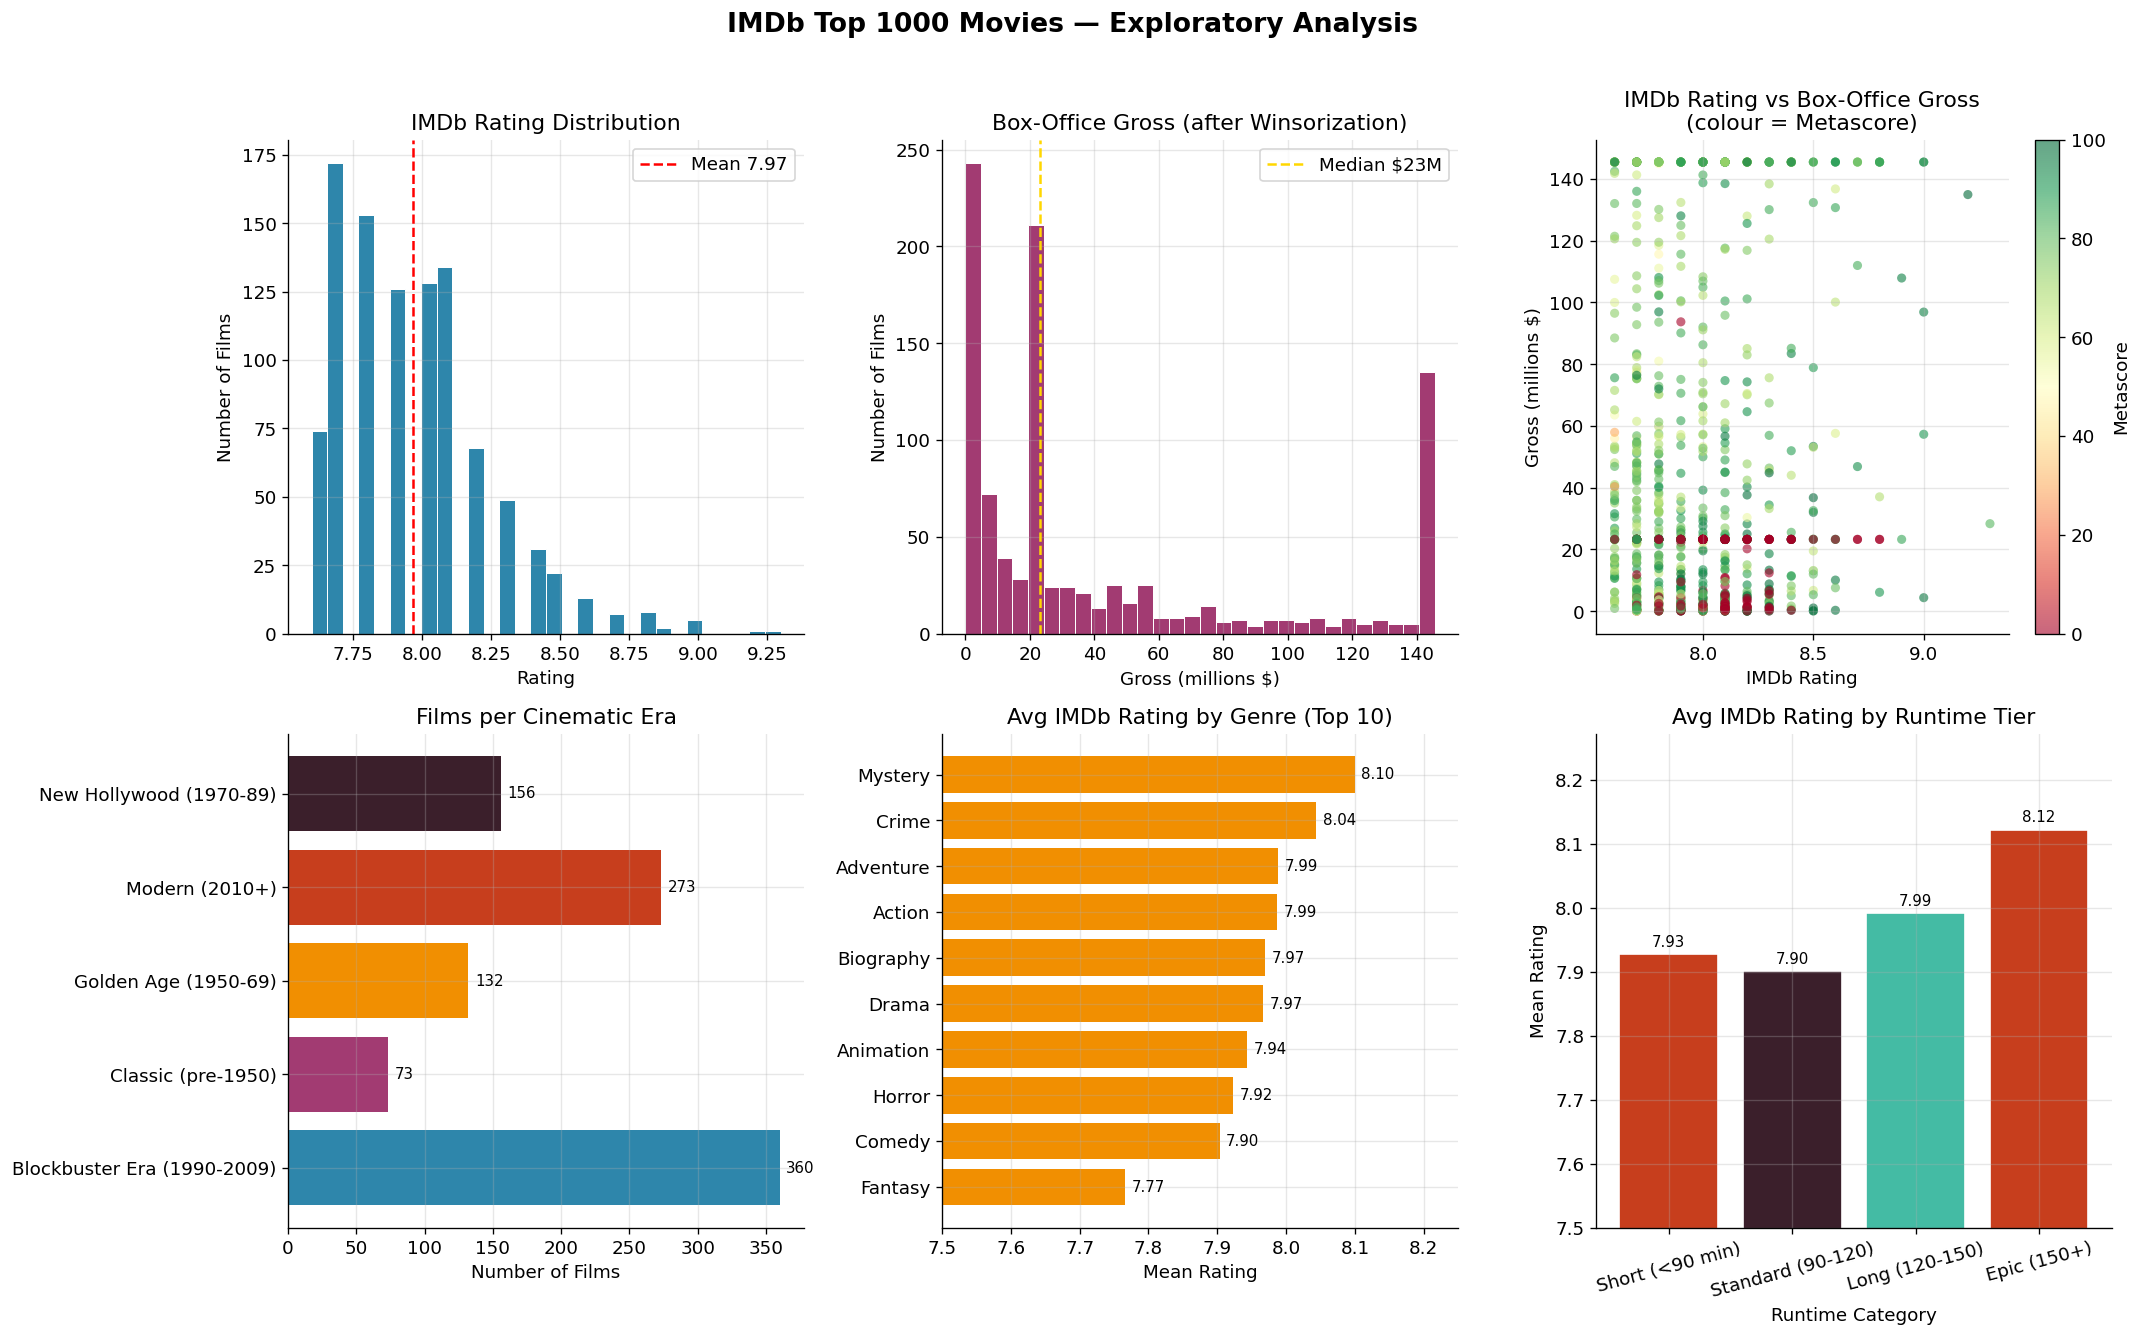

 Figure saved as imdb_analysis.png


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('IMDb Top 1000 Movies — Exploratory Analysis', fontsize=16, fontweight='bold', y=1.01)

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']

# ── 1. IMDb Rating Distribution ────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df_clean['rating'], bins=30, color=colors[0], edgecolor='white', linewidth=0.6)
ax.axvline(df_clean['rating'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean {df_clean['rating'].mean():.2f}")
ax.set_title('IMDb Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Films')
ax.legend()

# ── 2. Box-Office Gross Distribution (after Winsorization) ─────────────────
ax = axes[0, 1]
ax.hist(df_clean['gross'].dropna(), bins=30, color=colors[1], edgecolor='white', linewidth=0.6)
ax.axvline(df_clean['gross'].median(), color='gold', linestyle='--', linewidth=1.5, label=f"Median ${df_clean['gross'].median():.0f}M")
ax.set_title('Box-Office Gross (after Winsorization)')
ax.set_xlabel('Gross (millions $)')
ax.set_ylabel('Number of Films')
ax.legend()

# ── 3. Rating vs Gross — Scatter ───────────────────────────────────────────
ax = axes[0, 2]
scatter = ax.scatter(
    df_clean['rating'], df_clean['gross'],
    c=df_clean['metascore'], cmap='RdYlGn',
    alpha=0.6, s=30, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Metascore')
ax.set_title('IMDb Rating vs Box-Office Gross\n(colour = Metascore)')
ax.set_xlabel('IMDb Rating')
ax.set_ylabel('Gross (millions $)')

# ── 4. Films per Cinematic Era ─────────────────────────────────────────────
ax = axes[1, 0]
era_counts = df_clean['era'].value_counts().sort_index()
bars = ax.barh(era_counts.index, era_counts.values, color=colors[:len(era_counts)])
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Films per Cinematic Era')
ax.set_xlabel('Number of Films')

# ── 5. Average Rating by Primary Genre (top 10 genres) ────────────────────
ax = axes[1, 1]
top_genres  = df_clean['primary_genre'].value_counts().head(10).index
genre_means = (
    df_clean[df_clean['primary_genre'].isin(top_genres)]
    .groupby('primary_genre')['rating']
    .mean()
    .sort_values(ascending=True)
)
bars2 = ax.barh(genre_means.index, genre_means.values, color=colors[2])
ax.set_xlim(7.5, genre_means.max() + 0.15)
ax.bar_label(bars2, fmt='%.2f', padding=4, fontsize=9)
ax.set_title('Avg IMDb Rating by Genre (Top 10)')
ax.set_xlabel('Mean Rating')

# ── 6. Runtime Tier vs Avg Rating ─────────────────────────────────────────
ax = axes[1, 2]
rt_rating = df_clean.groupby('runtime_tier', observed=True)['rating'].mean()
bars3 = ax.bar(rt_rating.index, rt_rating.values, color=colors[3:3+len(rt_rating)], edgecolor='white')
ax.set_ylim(7.5, rt_rating.max() + 0.15)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('Avg IMDb Rating by Runtime Tier')
ax.set_xlabel('Runtime Category')
ax.set_ylabel('Mean Rating')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('imdb_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Figure saved as imdb_analysis.png")


In [24]:
df_clean.to_csv("imdb_clean.csv", index=False)

---
## Project Summary

| Requirement | Status |
|-------------|--------|
| Dataset ≥ 500 rows |  1 000 rows |
| Data Import & Exploration |  Section A |
| NumPy vectorised operations |  Section B (Z-score, Min-Max, Pearson r) |
| Sorting & Ranking |  Section C |
| Statistical summary (`describe`) |  Section C |
| Missing data handling |  Section D.1 (median imputation) |
| Duplicate removal | Section D.2 |
| `map()` & `apply()` transformations |  Section D.3 |
| Discretization (`pd.cut` + `pd.qcut`) | Section D.4 |
| Outlier detection & handling |  Section D.5 (IQR + Winsorization) |
| Markdown explanations throughout |  All sections |
| Matplotlib visualisations (Bonus) |  6 charts |
